# Exploratory Data Analysis (EDA) – Loan Prediction Dataset

## Objective
The goal of this analysis is to understand the structure, distribution, and relationships within the loan dataset before building a machine learning model.

This includes:
- Dataset overview
- Missing value analysis
- Target variable analysis
- Statistical summary
- Correlation analysis

In [10]:
!pip install kaggle --quiet

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ksaivardhangoud","key":"8eb1bfbeaa469b52cbd57d27899c82e5"}'}

In [11]:
!mkdir ~/.kaggle

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [12]:
!cp kaggle.json ~/.kaggle/

In [14]:
!chmod 600 ~/.kaggle/kaggle.json

In [15]:
!kaggle datasets download -d hossamhibrahem/loan-prediction-analytics-vidhya

Dataset URL: https://www.kaggle.com/datasets/hossamhibrahem/loan-prediction-analytics-vidhya
License(s): unknown
loan-prediction-analytics-vidhya.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip loan-prediction-analytics-vidhya.zip

Archive:  loan-prediction-analytics-vidhya.zip
replace sample_submission_49d68Cx.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Loading

The dataset is loaded into a pandas DataFrame for analysis.

In [18]:
!ls


kaggle.json			      sample_submission_49d68Cx.csv
loan-prediction-analytics-vidhya.zip  test_lAUu6dG.csv
sample_data			      train_ctrUa4K.csv


In [9]:
df = pd.read_csv("train_ctrUa4K.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Dataset Overview

We first examine:
- Number of rows and columns
- Data types
- Missing values

In [ ]:
df.shape

(614, 13)

The dataset contains 614 rows and 13 columns.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


From the dataset information:
- There are 8 categorical (object) columns.
- There are 5 numerical columns.
- Some columns contain missing values.

## Missing Value Analysis

We check the number of missing values in each column.

In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


Missing values are present in:
- LoanAmount
- Loan_Amount_Term
- Credit_History
- Self_Employed
- Dependents
- Gender

## Statistical Summary (Numerical Features)

We analyze the distribution of numerical features.

In [ ]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


Observations:
- ApplicantIncome is right-skewed (mean > median).
- LoanAmount shows variability with possible outliers.
- Most Loan_Amount_Term values are 360 months.

## Categorical Feature Summary

In [ ]:
df.describe(include="object")

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP002990,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


## Target Variable Analysis

The target variable is `Loan_Status`.
This is a binary classification problem.

In [ ]:
df['Loan_Status'].value_counts()

,count
Loan_Status,
Y,422
N,192


In [ ]:
df['Loan_Status'].value_counts(normalize=True)*100

,proportion
Loan_Status,
Y,68.729642
N,31.270358


The dataset is slightly imbalanced:
- ~69% Approved (Y)
- ~31% Rejected (N)

## Loan Status Distribution

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

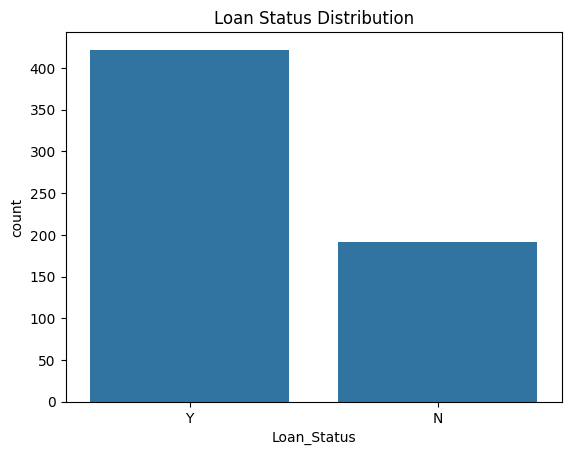

In [ ]:
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Status Distribution")
plt.show()

## Correlation Heatmap (Numerical Features)

Correlation measures the strength of linear relationship between numerical variables.

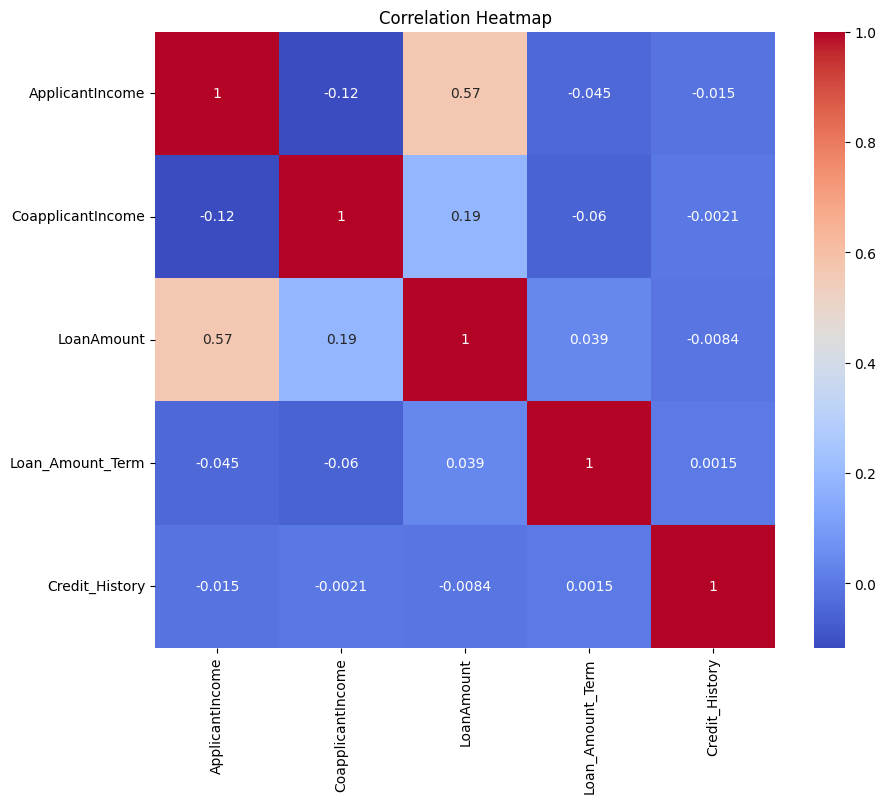

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Key Observations:
- ApplicantIncome and LoanAmount show moderate positive correlation.
- CoapplicantIncome has weak correlation with LoanAmount.
- No extremely high correlations detected.

# Final Observations

1. The dataset contains 614 records and 13 features.
2. The problem is a supervised binary classification task.
3. The target variable is Loan_Status.
4. The dataset is slightly imbalanced (69% vs 31%).
5. Missing values exist in key financial features.
6. ApplicantIncome is right-skewed due to high-income outliers.
7. LoanAmount is moderately correlated with ApplicantIncome.

This structured EDA provides a foundation for data cleaning and model building.